In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = {
    "Area": [
        800, 1000, 1200, 1500, 1800,
        2000, 2200, 2500, 2800, 3000,
        1100, 1300, 1600, 1900, 2100
    ],

    "Bedrooms": [
        2, 2, 3, 3, 3,
        4, 4, 4, 5, 5,
        2, 3, 3, 4, 4
    ],

    "Age": [
        20, 15, 12, 10, 8,
        7, 5, 4, 3, 2,
        18, 14, 11, 9, 6
    ],

    "Price": [
        45, 55, 68, 82, 95,
        110, 125, 145, 165, 180,
        60, 72, 88, 102, 118
    ]
}

df = pd.DataFrame(data)

In [3]:
df

,Area,Bedrooms,Age,Price
0,800,2,20,45
1,1000,2,15,55
2,1200,3,12,68
3,1500,3,10,82
4,1800,3,8,95
5,2000,4,7,110
6,2200,4,5,125
7,2500,4,4,145
8,2800,5,3,165
9,3000,5,2,180


In [4]:
df = pd.DataFrame(data)

In [5]:
df

,Area,Bedrooms,Age,Price
0,800,2,20,45
1,1000,2,15,55
2,1200,3,12,68
3,1500,3,10,82
4,1800,3,8,95
5,2000,4,7,110
6,2200,4,5,125
7,2500,4,4,145
8,2800,5,3,165
9,3000,5,2,180


In [6]:
df.head()

,Area,Bedrooms,Age,Price
0,800,2,20,45
1,1000,2,15,55
2,1200,3,12,68
3,1500,3,10,82
4,1800,3,8,95


In [7]:
df.shape

(15, 4)

In [8]:
df.shape

(15, 4)

In [9]:
df.columns

Index(['Area', 'Bedrooms', 'Age', 'Price'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      15 non-null     int64
 1   Bedrooms  15 non-null     int64
 2   Age       15 non-null     int64
 3   Price     15 non-null     int64
dtypes: int64(4)
memory usage: 612.0 bytes


In [11]:
df.describe()

,Area,Bedrooms,Age,Price
count,15.000000,15.000000,15.000000,15.000000
mean,1786.666667,3.400000,9.600000,100.666667
std,659.942277,0.985611,5.422177,40.220227
min,800.000000,2.000000,2.000000,45.000000
25%,1250.000000,3.000000,5.500000,70.000000
50%,1800.000000,3.000000,9.000000,95.000000
75%,2150.000000,4.000000,13.000000,121.500000
max,3000.000000,5.000000,20.000000,180.000000


In [12]:
df.isnull().sum()

Area        0
Bedrooms    0
Age         0
Price       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

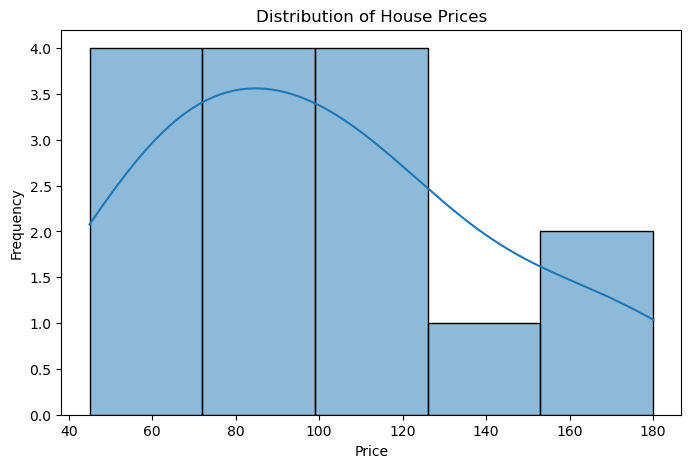

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

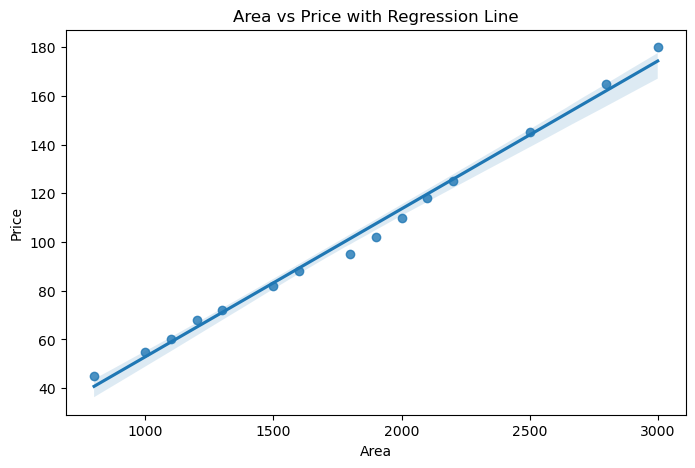

In [15]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Area",
    y="Price"
)

plt.title("Area vs Price with Regression Line")

plt.show()

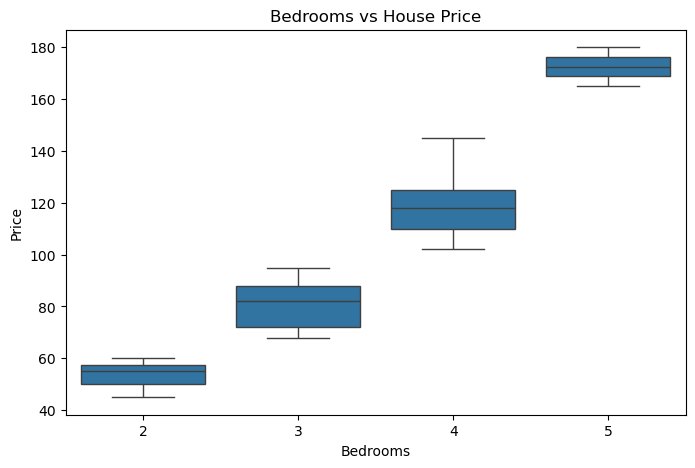

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Price"
)

plt.title("Bedrooms vs House Price")

plt.show()

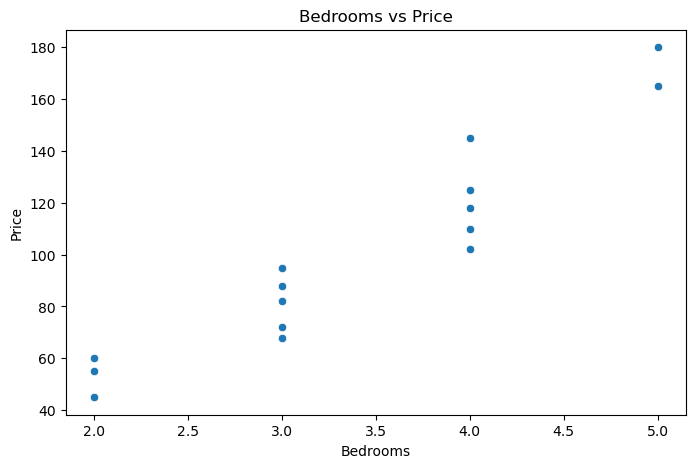

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Bedrooms",
    y="Price"
)

plt.title("Bedrooms vs Price")

plt.show()

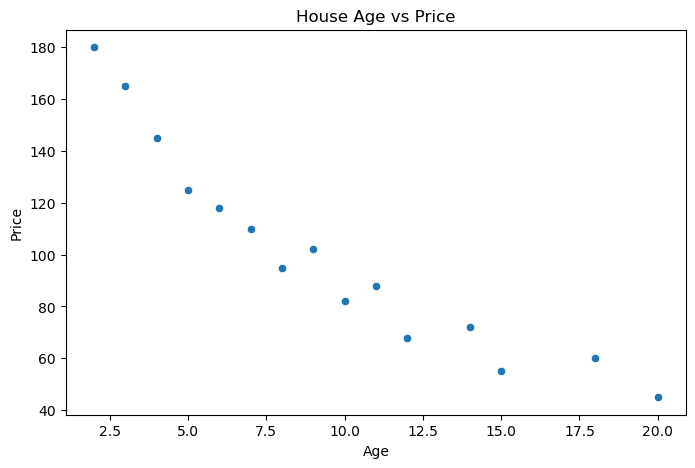

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Price"
)

plt.title("House Age vs Price")
plt.xlabel("Age")
plt.ylabel("Price")

plt.show()

In [17]:
correlation = df.corr(numeric_only=True)

correlation

,Area,Bedrooms,Age,Price
Area,1.000000,0.953192,-0.953759,0.996316
Bedrooms,0.953192,1.000000,-0.930255,0.947780
Age,-0.953759,-0.930255,1.000000,-0.937724
Price,0.996316,0.947780,-0.937724,1.000000


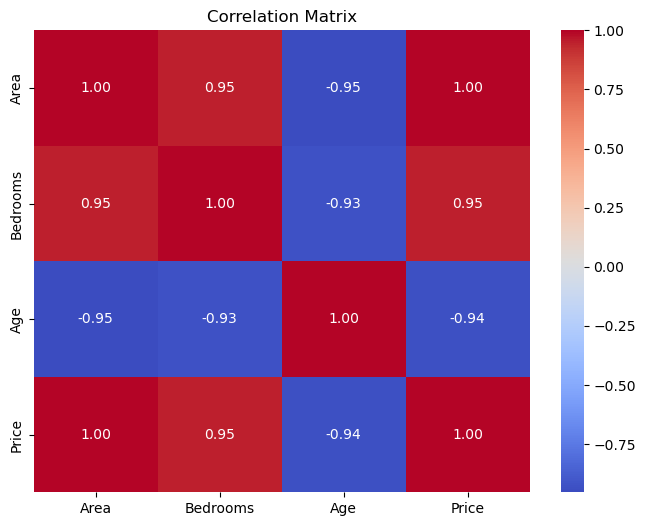

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
df[["Area", "Bedrooms", "Age"]].corr()

,Area,Bedrooms,Age
Area,1.000000,0.953192,-0.953759
Bedrooms,0.953192,1.000000,-0.930255
Age,-0.953759,-0.930255,1.000000


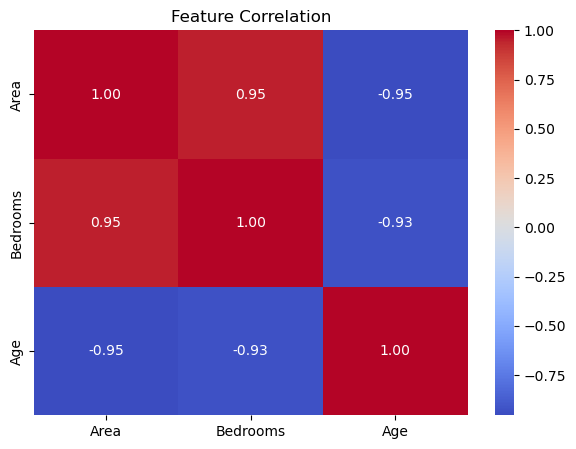

In [20]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df[["Area", "Bedrooms", "Age"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation")

plt.show()

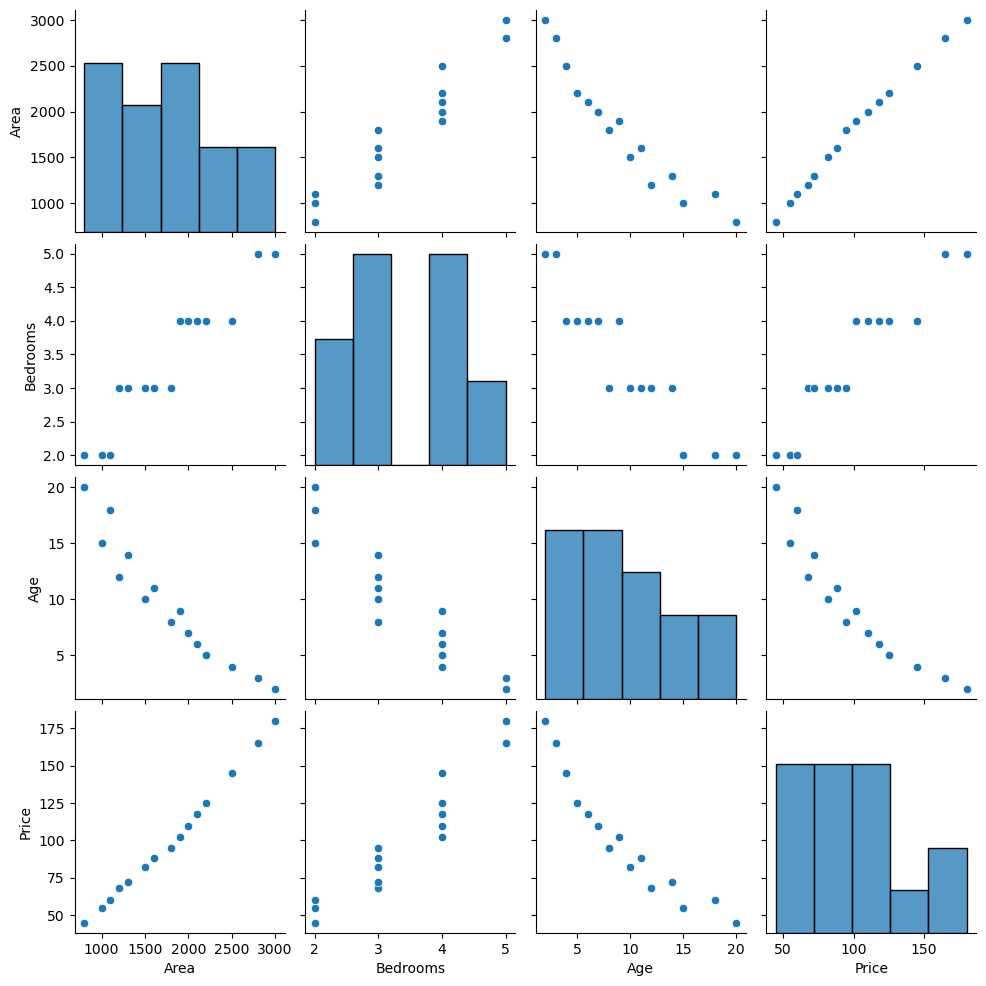

In [21]:
sns.pairplot(df)

plt.show()

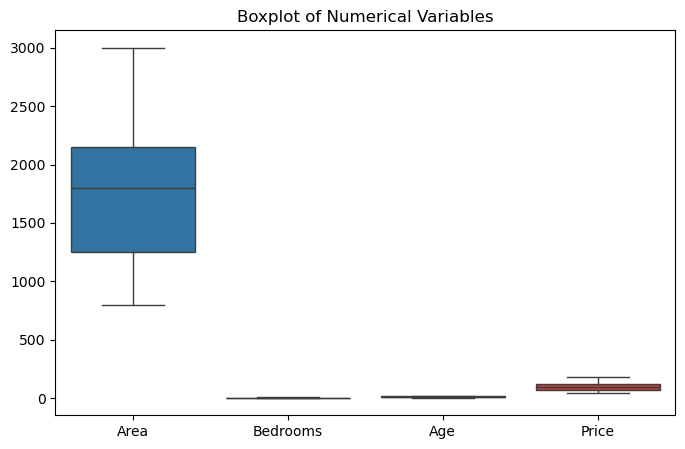

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df)

plt.title("Boxplot of Numerical Variables")

plt.show()

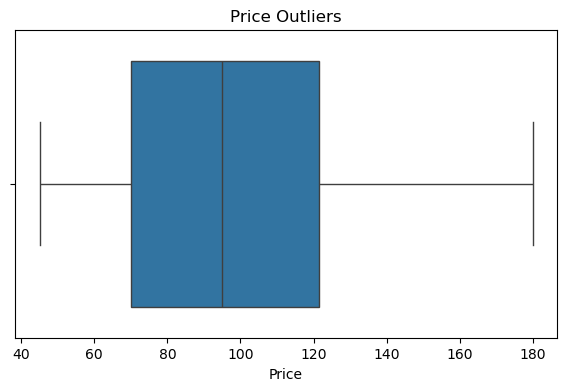

In [23]:
plt.figure(figsize=(7, 4))

sns.boxplot(x=df["Price"])

plt.title("Price Outliers")

plt.show()

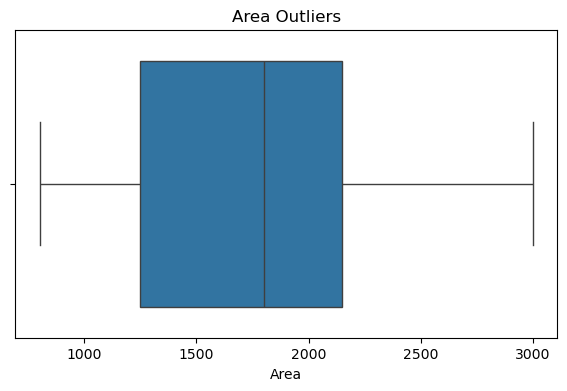

In [24]:
plt.figure(figsize=(7, 4))

sns.boxplot(x=df["Area"])

plt.title("Area Outliers")

plt.show()

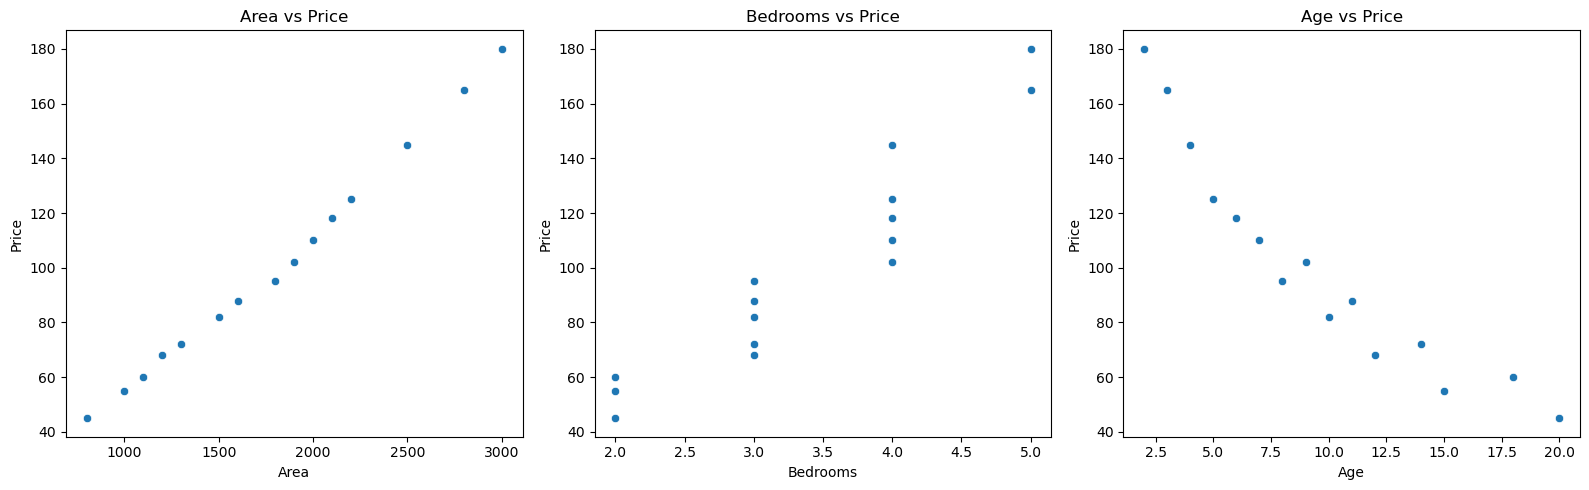

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(
    data=df,
    x="Area",
    y="Price",
    ax=axes[0]
)

axes[0].set_title("Area vs Price")

sns.scatterplot(
    data=df,
    x="Bedrooms",
    y="Price",
    ax=axes[1]
)

axes[1].set_title("Bedrooms vs Price")

sns.scatterplot(
    data=df,
    x="Age",
    y="Price",
    ax=axes[2]
)

axes[2].set_title("Age vs Price")

plt.tight_layout()
plt.show()

In [26]:
X = df[["Area", "Bedrooms", "Age"]]

y = df["Price"]

In [27]:
X.head()

,Area,Bedrooms,Age
0,800,2,20
1,1000,2,15
2,1200,3,12
3,1500,3,10
4,1800,3,8


In [28]:
y.head()

0    45
1    55
2    68
3    82
4    95
Name: Price, dtype: int64

In [29]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15, 3)
y shape: (15,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12, 3)
X_test: (3, 3)
y_train: (12,)
y_test: (3,)


In [32]:
random_state=42

In [33]:
model = LinearRegression()

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
print(model.coef_)

[0.06357863 0.21189872 0.49428882]


In [38]:
print(model.coef_)

[0.06357863 0.21189872 0.49428882]


In [39]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Area,0.063579
1,Bedrooms,0.211899
2,Age,0.494289


In [40]:
print(model.intercept_)

-19.060601667270745


In [41]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: -19.060601667270745
Area : 0.0635786257960959
Bedrooms : 0.211898721068704
Age : 0.49428882100139804


In [42]:
y_pred = model.predict(X_test)

In [43]:
print(y_pred)

[173.72334697  71.14735152  42.11187283]


In [44]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results

,Actual,Predicted
0,180,173.723347
1,72,71.147352
2,45,42.111873


In [45]:
results["Residual"] = (
    results["Actual"] - results["Predicted"]
)

results

,Actual,Predicted,Residual
0,180,173.723347,6.276653
1,72,71.147352,0.852648
2,45,42.111873,2.888127


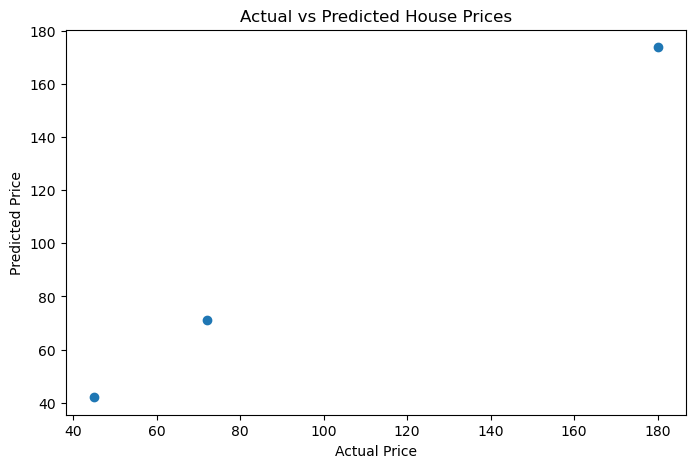

In [46]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

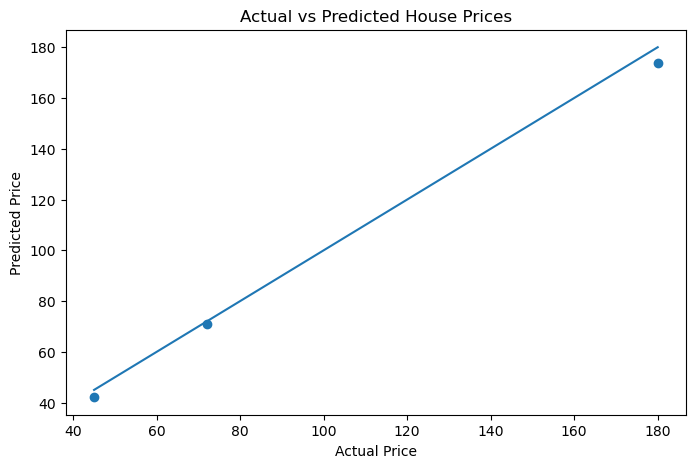

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [48]:
actual = np.array([100, 120, 150, 180, 200])

predicted = np.array([90, 125, 140, 190, 185])

In [49]:
errors = actual - predicted

print(errors)

[ 10  -5  10 -10  15]


In [50]:
absolute_errors = np.abs(errors)

print(absolute_errors)

[10  5 10 10 15]


In [51]:
mae_manual = np.mean(absolute_errors)

print(mae_manual)

10.0


In [52]:
mae_sklearn = mean_absolute_error(
    actual,
    predicted
)

print(mae_sklearn)

10.0


In [53]:
squared_errors = errors ** 2

print(squared_errors)

[100  25 100 100 225]


In [54]:
mse_manual = np.mean(squared_errors)

print(mse_manual)

110.0


In [55]:
mse_sklearn = mean_squared_error(
    actual,
    predicted
)

print(mse_sklearn)

110.0


In [56]:
rmse_manual = np.sqrt(mse_manual)

print(rmse_manual)

10.488088481701515


In [57]:
rmse_sklearn = np.sqrt(
    mean_squared_error(actual, predicted)
)

print(rmse_sklearn)

10.488088481701515


In [58]:
rmse_sklearn = np.sqrt(
    mean_squared_error(actual, predicted)
)

print(rmse_sklearn)

10.488088481701515


In [59]:
mean_actual = np.mean(actual)

rss = np.sum(
    (actual - predicted) ** 2
)

tss = np.sum(
    (actual - mean_actual) ** 2
)

r2_manual = 1 - (rss / tss)

print(r2_manual)

0.9191176470588235


In [60]:
r2_sklearn = r2_score(
    actual,
    predicted
)

print(r2_sklearn)

0.9191176470588235


In [61]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2_sklearn)
    * (n - 1)
    / (n - p - 1)
)

print(adjusted_r2)

1.161764705882353


In [62]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2)
    * (n - 1)
    / (n - p - 1)
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 3.3391428916619312
MSE: 16.154887080513394
RMSE: 4.019314255008358
R²: 0.9952513559434117
Adjusted R²: 1.0094972881131765


In [63]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2)
    * (n - 1)
    / (n - p - 1)
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 3.3391428916619312
MSE: 16.154887080513394
RMSE: 4.019314255008358
R²: 0.9952513559434117
Adjusted R²: 1.0094972881131765


In [64]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Residual"] = (
    results["Actual"] - results["Predicted"]
)

results

,Actual,Predicted,Residual
0,180,173.723347,6.276653
1,72,71.147352,0.852648
2,45,42.111873,2.888127


In [65]:
print(results)

   Actual   Predicted  Residual
0     180  173.723347  6.276653
1      72   71.147352  0.852648
2      45   42.111873  2.888127


In [67]:
results["Absolute_Error"] = (
    results["Actual"] - results["Predicted"]
).abs()

results.sort_values(
    "Absolute_Error",
    ascending=False
)

,Actual,Predicted,Residual,Absolute_Error
0,180,173.723347,6.276653,6.276653
2,45,42.111873,2.888127,2.888127
1,72,71.147352,0.852648,0.852648


In [68]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Residual"] = (
    results["Actual"] - results["Predicted"]
)

results

,Actual,Predicted,Residual
0,180,173.723347,6.276653
1,72,71.147352,0.852648
2,45,42.111873,2.888127


In [69]:
results["Absolute_Error"] = (
    results["Actual"] - results["Predicted"]
).abs()

results.sort_values(
    "Absolute_Error",
    ascending=False
)

,Actual,Predicted,Residual,Absolute_Error
0,180,173.723347,6.276653,6.276653
2,45,42.111873,2.888127,2.888127
1,72,71.147352,0.852648,0.852648


In [70]:
worst_prediction = results.loc[
    results["Absolute_Error"].idxmax()
]

worst_prediction

Actual            180.000000
Predicted         173.723347
Residual            6.276653
Absolute_Error      6.276653
Name: 0, dtype: float64

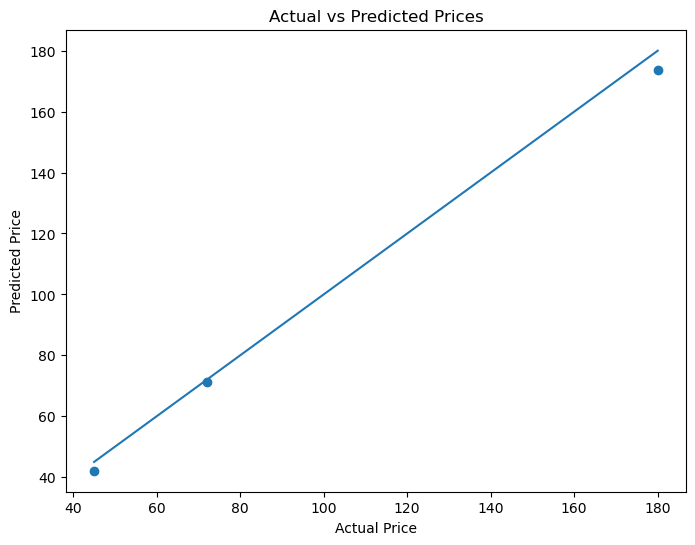

In [71]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [72]:
residuals = y_test - y_pred

In [73]:
print(residuals)

9     6.276653
11    0.852648
0     2.888127
Name: Price, dtype: float64


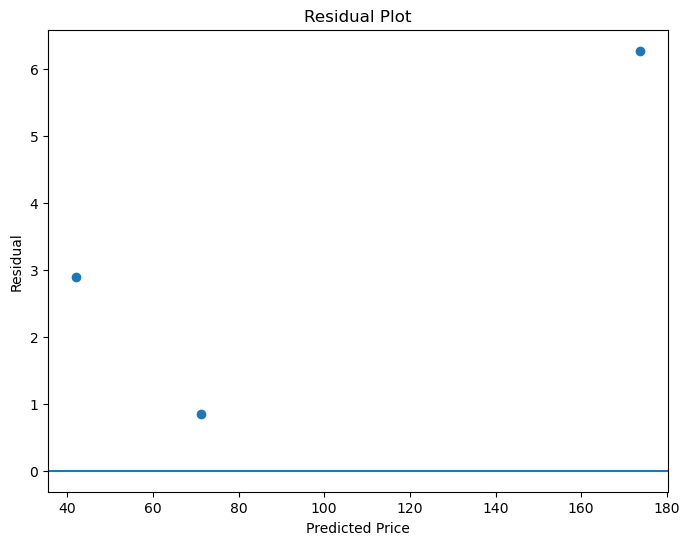

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

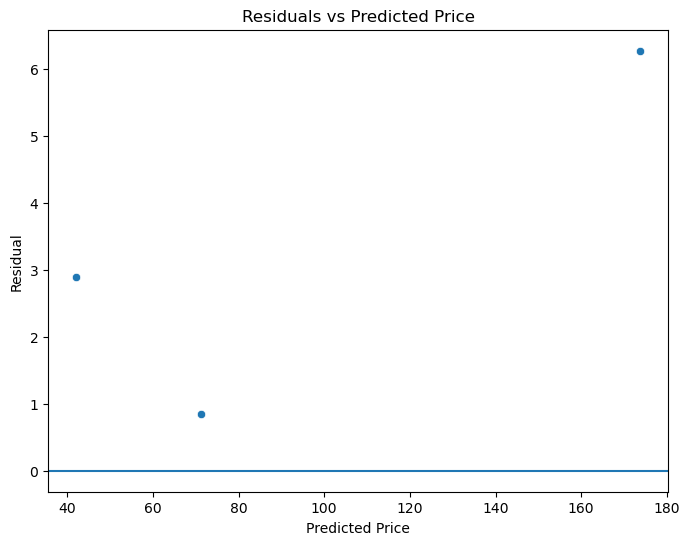

In [75]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residuals vs Predicted Price")

plt.show()

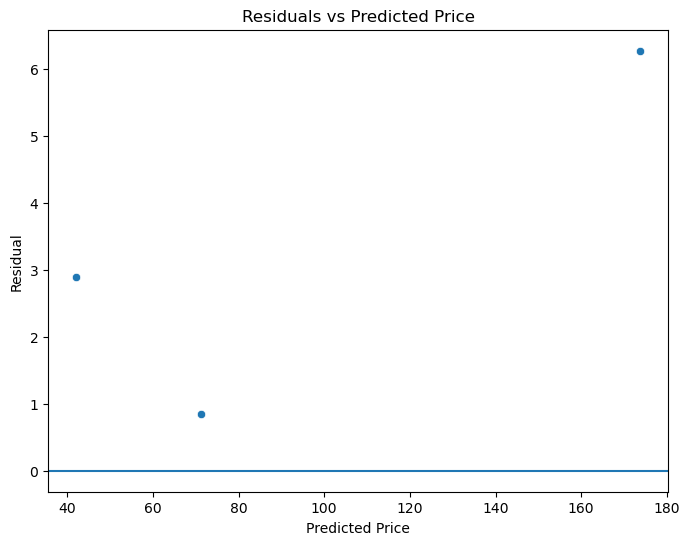

In [76]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residuals vs Predicted Price")

plt.show()

In [77]:
print("Mean residual:", residuals.mean())

Mean residual: 3.3391428916619312


In [78]:
y_train_pred = model.predict(X_train)

In [79]:
train_r2 = r2_score(
    y_train,
    y_train_pred
)

In [80]:
test_r2 = r2_score(
    y_test,
    y_pred
)

In [81]:
print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.9920066926028284
Testing R²: 0.9952513559434117


In [82]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train MAE: 2.268829285973176
Test MAE: 3.3391428916619312


In [83]:
train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 2.8775588344012815
Test RMSE: 4.019314255008358


In [84]:
evaluation = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],

    "Train": [
        train_mae,
        train_rmse,
        train_r2
    ],

    "Test": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

evaluation

,Metric,Train,Test
0,MAE,2.268829,3.339143
1,RMSE,2.877559,4.019314
2,R²,0.992007,0.995251


In [85]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
new_house = pd.DataFrame({
    "Area": [1700],
    "Bedrooms": [3],
    "Age": [5]
})

new_house

,Area,Bedrooms,Age
0,1700,3,5


In [87]:
new_prediction = model.predict(new_house)

print(new_prediction)

[92.13020245]


In [88]:
print(
    "Predicted House Price:",
    new_prediction[0]
)

Predicted House Price: 92.13020245430538


In [89]:
new_houses = pd.DataFrame({
    "Area": [1200, 1700, 2200, 2800],
    "Bedrooms": [2, 3, 4, 5],
    "Age": [15, 5, 7, 3]
})

In [90]:
predictions = model.predict(new_houses)

predictions

array([ 65.07187905,  92.13020245, 125.11999172, 161.50191063])

In [91]:
prediction_results = new_houses.copy()

prediction_results["Predicted_Price"] = predictions

prediction_results

,Area,Bedrooms,Age,Predicted_Price
0,1200,2,15,65.071879
1,1700,3,5,92.130202
2,2200,4,7,125.119992
3,2800,5,3,161.501911
